In [62]:
import cv2 as cv
import cv2

import matplotlib.pyplot as plt

import numpy as np

from skimage import filters
from skimage import feature
from scipy.ndimage import distance_transform_edt
from skimage import morphology,segmentation
from skimage import color
from sklearn.cluster import KMeans
from skimage import measure
import scipy.ndimage as ndi

from Sobel import sobel

In [106]:
#Create lista for all result that will be measured
images1=[]
pores1=[]
calssits=[]
porosities=[] 

In [107]:
img_name = 'Lamina_1.jpg'
img_c = cv2.imread(img_name)
#convert image to gray scale
img_gray = cv2.cvtColor(img_c, cv2.COLOR_BGR2GRAY) 

In [108]:
#Measure the size of the image
dim=img_c.shape
size=dim[0]*dim[1]

In [109]:
#Using filters to denoise the images
blur = cv.GaussianBlur(img_gray,(1,1),0)
median= cv2.medianBlur(blur,1)
img = filters.median(median, np.ones((1,1)))

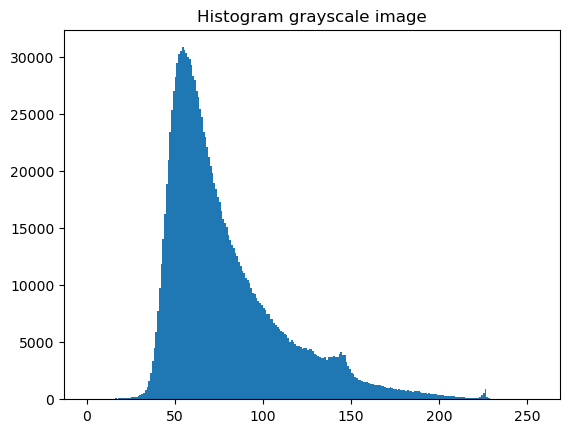

In [110]:
# Histogram gray scale of the images
plt.hist(img_gray.ravel(),256,[0, 256])
plt.title('Histogram grayscale image')
plt.show() 

In [111]:
#Using threshold with range[100,255] that was extracted from histogram
ret,gaus = cv2.threshold(img_gray,50,225,1)

In [112]:
#Fonding the fact edges location
laplacian_2 = cv2.Laplacian(gaus,cv2.CV_8U,-1) 

In [113]:
#Canny, dilation, and erosion detection using to detects,
#extends, and maintains the edges of the object
edged = cv2.Canny(laplacian_2,40,100)
edged = cv2.dilate(edged, None, iterations=1)
edged = cv2.erode(edged, None, iterations=1) 


In [114]:
#calculating Eucliden distance from each pixel to the background
dt = distance_transform_edt(~edged) 


In [115]:
#locate the peaks (peaks are separated by at least min_distance ;
# indices=TRUE : peak coordinates in output)peak_idx
# indices=FALSE : image with peaks in output)local_max
local_max = ndi.maximum_filter(dt, size=5, mode='constant')
#local_max = feature.peak_local_max(dt,exclude_border=False,min_distance=10)

# min_distance can be change to obtaine best observation through range(10,20)
peak_idx = feature.peak_local_max(dt, min_distance=5)

In [116]:

#Peaks label in the image
markers = measure.label(local_max) 

In [117]:
#Segment and do watershed on the image
labels = segmentation.watershed(-dt, markers)
seg=(segmentation.mark_boundaries(edged,labels))
#Split regions with their intensity in the image
regions = measure.regionprops(labels, intensity_image=img)
region_means = [r.mean_intensity for r in regions] 

In [118]:
#Choose the number of k_clusters K=3 clusters
# it can be change to obtain best observation through this range (1,4)
n_clusters=3
model = KMeans(n_clusters)

In [119]:
#Reshape the format of regions
region_means = np.array(region_means).reshape(-1, 1)
model.fit(region_means)

c:\Users\DELL\miniconda3\envs\python_v3.10\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3)

In [120]:
#Defind specific labels
three_labels = model.predict(region_means) 

In [121]:
#Return a copy of the array.
classified_labels = labels.copy() 

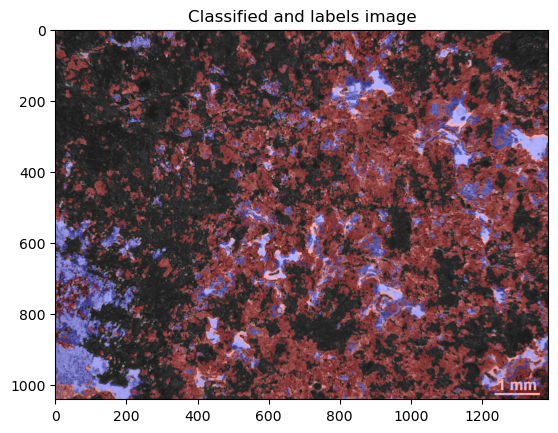

In [122]:
#Plott specific labels and colorize it for each images
for three, region in zip(three_labels, regions):
    classified_labels[tuple(region.coords.T)] = three
plt.imshow(color.label2rgb(classified_labels,image=img_c))
plt.title('Classified and labels image') 
#save the files to output folder with the name "Image_x"
filename = '\\output/image1%s.png'+img_name
#plt.colorbar()
# live image display
#plt.draw()
# need to add pause command, otherwise it does not work
#plt.pause(.01)
# clear the figure to avoid memory issues
#plt.clf()
#save these contours (outputs) as png with same file names
#cv2.imwrite(filename,color.label2rgb( classified_labels,image=img_c))

#plt.savefig('C:/Users/faree/OneDrive/Desctop/IA/aft/image1%f.png',dpi=400)

In [123]:
# To measure every labels from each image
area =[np.sum(classified_labels==val) for val in range(0,5)]
print('Area for each cluster',area)

ratio1 = 100 * np.sum(classified_labels == 0) / size
print ('Ratio1 is : ', round(ratio1,1),'%')

ratio2 = 100 * np.sum(classified_labels == 1) / size
print ('Ratio2 is : ', round(ratio2,1),'%')

ratio3 = 100 * np.sum(classified_labels == 2) / size
print ('Ratio3 is : ', round(ratio3,1),'%')


Area for each cluster [707831, 573767, 161922, 0, 0]
Ratio1 is :  49.0 %
Ratio2 is :  39.7 %
Ratio3 is :  11.2 %


In [124]:
#Defind shape of each image
hight,width = img.shape

In [125]:
#Using FinContous to measure each object value precisely and input values in the list

# calssit threshold
ret,gaus1 = cv2.threshold(img,100,255,0)
# Using filters
blur = cv.GaussianBlur(gaus1,(1,1),0)
median1 = cv2.medianBlur(blur,11)

In [126]:
#FinContours for calssit
contours1, hierarchy1 = cv2.findContours(median1,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
width,hight = gaus1.shape 

In [127]:
# extruct each area for calssit and insert #in liste contours
contours = []
Areal = 0
for i in range(1,len(contours1)):
    contours.append(contours1[i])
    a = cv.contourArea(contours1[i])
    Areal += a
pore=(Areal/size)*100

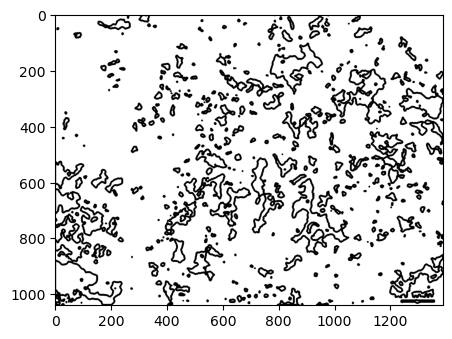

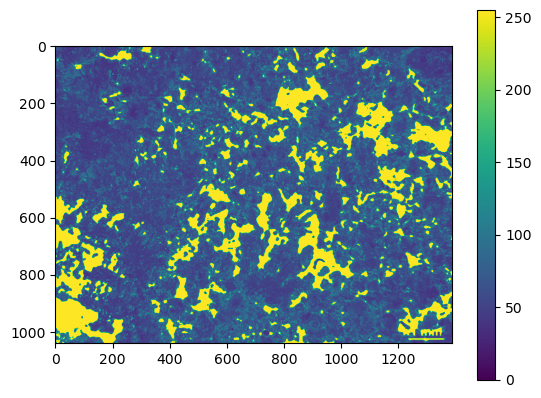

<Figure size 640x480 with 0 Axes>

In [128]:
#show clasit measure
e_img = np.full((width,hight), 255,np.uint8)
cv.drawContours(e_img,contours,-1, 0, thickness=5)
plt.figure(figsize=(5,5))
plt.imshow(e_img,cmap='gray')
plt.show()
cv2.drawContours(img,contours,-1,(255,255,0),-1)
plt.imshow(img)
plt.colorbar() 
# live image display
plt.draw()
# need to add pause command, otherwise it does not work
plt.pause(.01)
# clear the figure to avoid memory issues
plt.clf() 


In [129]:
#grains threshold with range obtained from histogram
ret,gaus2 = cv2.threshold(img,40,255,1) 
contours2, hierarchy2 = cv2.findContours(gaus2,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
width,hight = gaus2.shape
x = []
Area = 0
for i in range(1,len(contours2)):
    x.append(contours2[i])
    a2 = cv.contourArea(contours2[i])
    Area += a2
grains=(Area/size)*100

In [131]:
#pores measuring
calssit = 100 - pore

pores1.append(pore)

calssits.append(calssit)

In [135]:
pores1

[15.072115384615383]

In [136]:
calssits

[84.92788461538461]

In [137]:
grains

0.792022278873864

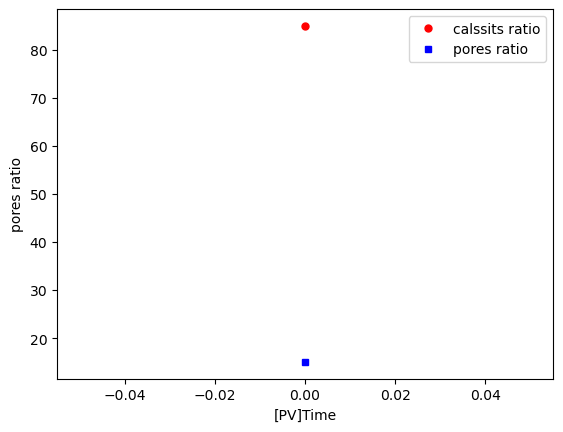

In [138]:
#Plott all measurements
plt.plot(calssits,'ro',markersize=5,label='calssits ratio')
plt.xlabel("[PV]Time")
plt.ylabel("Calssit ratio")
plt.legend(loc='best')
ax = plt.gca()

plt.plot(pores1,'bs',markersize=5,label='pores ratio') 

plt.xlabel("[PV]Time")
plt.ylabel("pores ratio")
plt.legend(loc='best')
ax = plt.gca() 